Dataset berhasil diekstrak!

Isi folder dataset:
['datasetbuah']

Gambar yang digunakan:
datasetbuah/datasetbuah/Fruits Classification/test/Apple/Apple (1133).jpeg

===== INFORMASI CITRA =====
Shape Gambar : (275, 183, 3)
Dtype Gambar : uint8


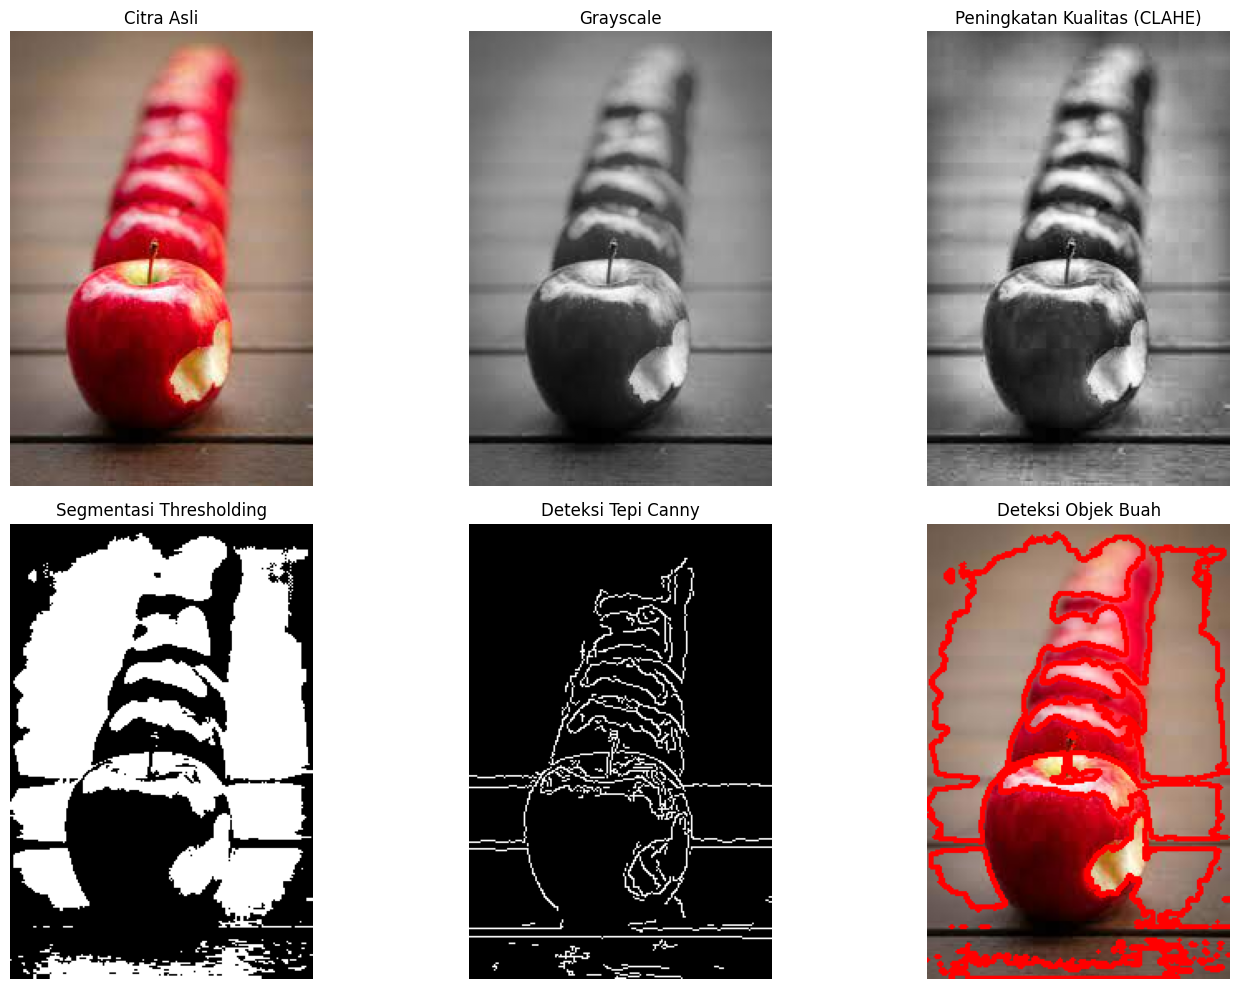


Jumlah Objek Buah Terdeteksi : 59


In [ ]:
# =========================================================
# SISTEM CERDAS DETEKSI BUAH DAN SEGMENTASI OBJEK
# MENGGUNAKAN OPENCV
# =========================================================

# =========================================================
# IMPORT LIBRARY
# =========================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# =========================================================
# EKSTRAK DATASET ZIP
# =========================================================

# Nama file zip
zip_file = 'datasetbuah.zip'

# Folder hasil ekstrak
extract_folder = 'datasetbuah'

# Mengekstrak file ZIP
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset berhasil diekstrak!")

# =========================================================
# MENAMPILKAN ISI FOLDER DATASET
# =========================================================

print("\nIsi folder dataset:")
print(os.listdir(extract_folder))

# =========================================================
# MENCARI FILE GAMBAR OTOMATIS
# =========================================================

image_path = None

for root, dirs, files in os.walk(extract_folder):
    for file in files:
        if file.endswith(('.jpg', '.jpeg', '.png')):
            image_path = os.path.join(root, file)
            break
    if image_path:
        break

# =========================================================
# MEMBACA GAMBAR
# =========================================================

if image_path is None:
    print("Tidak ada gambar ditemukan dalam dataset!")

else:

    print("\nGambar yang digunakan:")
    print(image_path)

    # Membaca gambar
    image = cv2.imread(image_path)

    # =====================================================
    # INFORMASI CITRA
    # =====================================================

    print("\n===== INFORMASI CITRA =====")
    print("Shape Gambar :", image.shape)
    print("Dtype Gambar :", image.dtype)

    # =====================================================
    # KONVERSI WARNA
    # =====================================================

    # BGR ke RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # RGB ke Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # =====================================================
    # PENINGKATAN KUALITAS CITRA (CLAHE)
    # =====================================================

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(gray)

    # =====================================================
    # SEGMENTASI OBJEK (THRESHOLDING)
    # =====================================================

    _, thresh = cv2.threshold(
        enhanced,
        127,
        255,
        cv2.THRESH_BINARY
    )

    # =====================================================
    # DETEKSI TEPI (CANNY)
    # =====================================================

    edges = cv2.Canny(
        enhanced,
        100,
        200
    )

    # =====================================================
    # MENCARI CONTOUR OBJEK
    # =====================================================

    contours, hierarchy = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Salinan gambar untuk contour
    contour_image = image_rgb.copy()

    # Menggambar contour
    cv2.drawContours(
        contour_image,
        contours,
        -1,
        (255, 0, 0),
        2
    )

    # =====================================================
    # MENAMPILKAN HASIL
    # =====================================================

    plt.figure(figsize=(15,10))

    # -----------------------------------------------------
    # Citra Asli
    # -----------------------------------------------------
    plt.subplot(2,3,1)
    plt.imshow(image_rgb)
    plt.title("Citra Asli")
    plt.axis('off')

    # -----------------------------------------------------
    # Grayscale
    # -----------------------------------------------------
    plt.subplot(2,3,2)
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale")
    plt.axis('off')

    # -----------------------------------------------------
    # CLAHE
    # -----------------------------------------------------
    plt.subplot(2,3,3)
    plt.imshow(enhanced, cmap='gray')
    plt.title("Peningkatan Kualitas (CLAHE)")
    plt.axis('off')

    # -----------------------------------------------------
    # Thresholding
    # -----------------------------------------------------
    plt.subplot(2,3,4)
    plt.imshow(thresh, cmap='gray')
    plt.title("Segmentasi Thresholding")
    plt.axis('off')

    # -----------------------------------------------------
    # Deteksi Tepi
    # -----------------------------------------------------
    plt.subplot(2,3,5)
    plt.imshow(edges, cmap='gray')
    plt.title("Deteksi Tepi Canny")
    plt.axis('off')

    # -----------------------------------------------------
    # Hasil Contour
    # -----------------------------------------------------
    plt.subplot(2,3,6)
    plt.imshow(contour_image)
    plt.title("Deteksi Objek Buah")
    plt.axis('off')

    # Menampilkan semua hasil
    plt.tight_layout()
    plt.show()

    # =====================================================
    # JUMLAH OBJEK
    # =====================================================

    print("\nJumlah Objek Buah Terdeteksi :", len(contours))